In [ ]:
import os
from typing import List, Dict
import mne
from tqdm import tqdm
tqdm.pandas()

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, welch


import warnings 
warnings.filterwarnings("ignore")


# sklearn packages 
from sklearn.model_selection import train_test_split


import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, 
                                     Reshape, 
                                    Input, 
                                    LSTM, 
                                    Dropout, 
                                    Conv1D, 
                                    MaxPooling1D,
                                    Conv2D, 
                                    MaxPooling2D, 
                                    GlobalAveragePooling1D, 
                                    Bidirectional,
                                    TimeDistributed,   
                                    Concatenate,
                                    Flatten
                                )
from tensorflow.keras.optimizers import (Adam,
                                         AdamW)
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report

In [7]:
print("TensorFlow version:", tf.__version__)
print("Available physical devices:")
print(tf.config.list_physical_devices())

print("\nIs MPS available?")
print(tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
Available physical devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Is MPS available?
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#### Custom Defined Functions

In [55]:
def psd_graph(band_psd:np.array, sample_index:int, sample_index_channel:int, band:str):
    psd_channel = band_psd[band][0][sample_index]
    psd_channel = psd_channel[sample_index_channel, :, :]
    plt.figure(figsize=(8, 5))
    plt.imshow(psd_channel, aspect='auto', origin='lower',
            extent=[0, psd_channel.shape[1], 0, 125])
    plt.colorbar(label="Power Spectral Density")
    plt.xlabel("Window index (each 25 points)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"PSD Heatmap — {band} band | Channel {sample_index_channel}")
    plt.show()

#### Step -1 : Load the Dataset

In [10]:
data = np.load("../eeg_processed/eeg_data_ICA.npz")
X, y = data["X"], data["y"]

print(f"Shape of X : {X.shape}")
print(f"Shape of y : {y.shape}")

Shape of X : (1799, 16, 500)
Shape of y : (1799,)


In [64]:
y[y == 2] = 0 
y[y == 3] = 1
y[y == 4] = 2 
y[y == 5] = 3
y[y == 6] = 4 
y[y == 7] = 5

print(np.unique(y))

[0 1 2 3 4 5]


#### Step -2 Generate the Power-Spectral Density 3D Representation

In [ ]:
fs = 250  # Sampling frequency in Hz (adjust if known)
window_size = 25  # 25 points per PSD computation

# EEG bands
freq_bands = {
    "delta": (0.5, 4.5),
    "theta": (4.5, 8.5),
    "alpha": (8.5, 11.5),
    "sigma": (11.5, 15.5),
    "beta": (15.5, 30.0),
}

In [ ]:
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, data, axis=-1)

def compute_psd_windows(data, fs, window_size=25):
    n_samples, n_channels, n_points = data.shape
    n_windows = n_points // window_size

    psd_all = []
    for w in range(n_windows):
        seg = data[:, :, w * window_size:(w + 1) * window_size]
        freqs, psd = welch(seg, fs=fs, nperseg=window_size, axis=-1)
        psd_all.append(psd)
    return np.stack(psd_all, axis=2), freqs  # shape: (n_samples, n_channels, n_freqs, n_windows)

def extract_band_psd(eeg_data, fs):
    """
    eeg_data: (n_samples, n_channels, n_timesteps)
    returns: dict {band_name: (PSD array, freqs)}
    """
    band_psd = {}

    for band_name, (low, high) in freq_bands.items():
        print(f"Processing {band_name} band ({low}-{high} Hz)")
        
        # Bandpass filter along time axis
        filtered = bandpass_filter(eeg_data, low, high, fs)
        
        # Compute PSD for 25-point segments
        psd_vals, freqs = compute_psd_windows(filtered, fs)
        band_psd[band_name] = (psd_vals, freqs)

    return band_psd

eeg_data = np.random.randn(1799, 16, 500)
band_psd = extract_band_psd(eeg_data, fs)
print(band_psd['alpha'][0].shape)  # (1799, 16, n_freqs, n_windows)

Processing delta band (0.5-4.5 Hz)
Processing theta band (4.5-8.5 Hz)
Processing alpha band (8.5-11.5 Hz)
Processing sigma band (11.5-15.5 Hz)
Processing beta band (15.5-30.0 Hz)
(1799, 16, 20, 13)


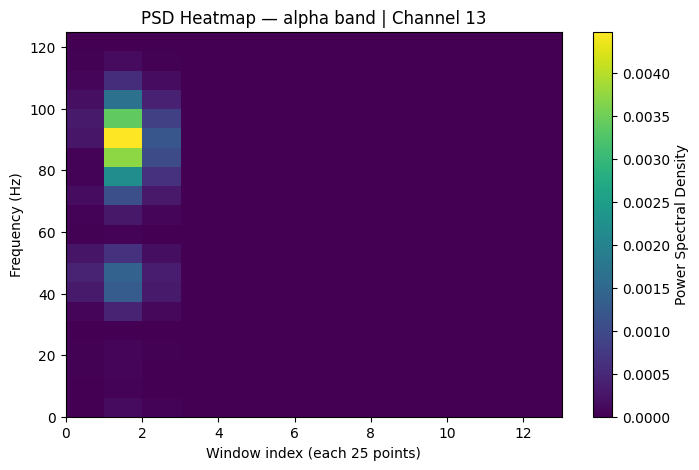

In [56]:
psd_graph(band_psd, sample_index= 12, sample_index_channel= 13, band= "alpha")

{'delta': (array([[[[1.56962173e-06, 3.02456023e-06, 5.10093002e-07, ...,
            2.81018106e-13, 1.20652254e-13, 5.96091159e-14],
           [7.68928693e-06, 7.55986532e-05, 5.72639423e-06, ...,
            5.99886772e-11, 1.90361263e-11, 3.13185470e-12],
           [1.62132104e-05, 3.88986807e-04, 2.26760594e-05, ...,
            2.85601547e-10, 8.65437482e-11, 9.23814812e-12],
           ...,
           [2.25399216e-05, 2.11202907e-04, 1.44445914e-05, ...,
            1.22961205e-10, 3.80799554e-11, 5.17723377e-12],
           [2.03521687e-10, 6.02153823e-04, 3.94024566e-05, ...,
            4.16733864e-10, 1.26123063e-10, 1.33318195e-11],
           [2.96010785e-05, 6.58681288e-05, 8.78229984e-06, ...,
            1.04213810e-11, 5.15102152e-12, 3.18262240e-12]],
  
          [[1.01096769e-04, 4.35683582e-04, 3.12337834e-05, ...,
            2.63152828e-10, 8.27549536e-11, 1.27555293e-11],
           [2.87918890e-05, 7.10264243e-05, 8.81935398e-06, ...,
            3.65407185e-